In [2]:
# # formatting the source data into train, test, validation
# import splitfolders

# input_folder = 'dataset'
# output_folder = 'split_dataset'

# splitfolders.ratio(
#     input_folder, 
#     output=output_folder, 
#     seed=1337, 
#     ratio=(0.8, 0.1, 0.1), 
#     group_prefix=None
# )

In [9]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# creating a transformation pipeline for the input data that resizes images, formats them as an n dimensional array, and then normalises the values
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(torch.Tensor(mean), torch.Tensor(std))
])

train_data = datasets.ImageFolder("split_dataset/train", transform=transform)
val_data   = datasets.ImageFolder("split_dataset/val", transform=transform)
test_data  = datasets.ImageFolder("split_dataset/test", transform=transform)

In [10]:
train_loader = DataLoader(train_data, batch_size=6, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=6, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=6, shuffle=False)

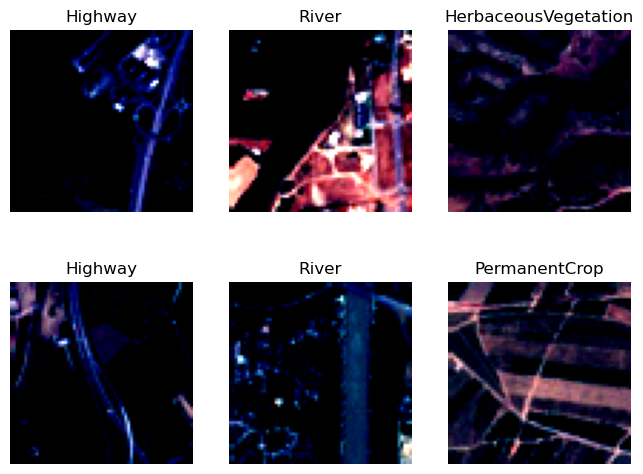

In [11]:
import matplotlib.pyplot as plt
import torchvision.utils as utils
import numpy as np

def display_images(loader):
    images, labels = next(iter(loader))
    class_names = train_data.classes

    fig, axes = plt.subplots(2, 3, figsize=(8, 6))
    axes = axes.flatten()

    for i in range(6):
        img = images[i].permute(1, 2, 0).numpy()

        axes[i].imshow(np.clip(img,0,1))
        axes[i].set_title(class_names[labels[i]])
        axes[i].axis("off")

    plt.show()

# visualisation of sample images being parsed to the CNN 
display_images(train_loader)

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        # class torch.nn.Conv2d(in_channels, out_channels, kernel_size)
        # class torch.nn.MaxPool2d(kernel_size)
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool = nn.MaxPool2d(2)
        # class torch.nn.Linear(in_features, out_features)
        self.fc1 = nn.Linear(13 * 13 * 16, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        # output dimensions = input dimensions - kernel size + 1 
        
        # input to conv1 is [6,3, 64, 64], output is [6, 6, 60, 60] further halved by pooling [6, 6, 30, 30]
        x = self.pool(F.relu(self.conv1(x)))

        # input to conv2 is [6, 6, 30, 30], output is [6, 16 (output channels), 26, 26] further halved by pooling [6, 16, 13, 13]
        x = self.pool(F.relu(self.conv2(x)))

        # transforms input into a n x 1 vector
        # hence 13 x 13 x 16 output channels
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # output dimensions of linear transformation 3 must match the number of classes as these are the logits used in cross entropy loss calculation
        x = self.fc3(x)
        return x

net = Net()

In [13]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = net.to(device)

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimiser = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [17]:
for epoch in range(20):

    net.train()
    running_loss = 0
    
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        # clear the gradients from previous epoch
        optimiser.zero_grad()

        # complete the forward pass
        output = net(inputs)

        # forward loss computation
        loss = criterion(output, labels)

        # take a stochastic batch of data points and uses their gradient wrt loss to optimise incrementally (stochastic gradient descent)
        loss.backward()
        optimiser.step()

        running_loss += loss.item()

    net.eval()

    val_loss = 0

    with torch.no_grad():
        for data in val_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
        
    print("Epoch:", epoch+1,
          "Train Loss:", running_loss/len(train_loader),
          "Val Loss:", val_loss/len(val_loader))

print("Finished training")

Epoch: 1 Train Loss: 0.19414122792931368 Val Loss: 0.9248215919615702
Epoch: 2 Train Loss: 0.17136297343360285 Val Loss: 1.2102514657113947
Epoch: 3 Train Loss: 0.1659401603349574 Val Loss: 1.2920773492557662
Epoch: 4 Train Loss: 0.15298470885891322 Val Loss: 1.0643108934129453
Epoch: 5 Train Loss: 0.13357259935655355 Val Loss: 1.1282026116654706
Epoch: 6 Train Loss: 0.09893046147429718 Val Loss: 1.2602396043278932
Epoch: 7 Train Loss: 0.09799227828271405 Val Loss: 1.2571314759676149
Epoch: 8 Train Loss: 0.12687859709068364 Val Loss: 1.2963160197595143
Epoch: 9 Train Loss: 0.08050510742808535 Val Loss: 1.3650464414400485
Epoch: 10 Train Loss: 0.08396230664471416 Val Loss: 1.4285902453779962
Epoch: 11 Train Loss: 0.08314839922999659 Val Loss: 1.4916925523125313
Epoch: 12 Train Loss: 0.052603587877172 Val Loss: 1.5130145418959349
Epoch: 13 Train Loss: 0.08964593954907309 Val Loss: 1.43330230997786
Epoch: 14 Train Loss: 0.06345463641152665 Val Loss: 1.650068447111059
Epoch: 15 Train Loss: